In [15]:
import importlib
import NeuralNetwork
import funcs
import plots

importlib.reload(NeuralNetwork)
importlib.reload(funcs)
importlib.reload(plots)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import defaultdict
import numpy as np
from tqdm.auto import tqdm
import copy
import os

In [3]:
import importlib
import setup
importlib.reload(setup)
from setup import N_CLUSTERS, BATCH_SIZE

device = setup.get_device()
batch_size = BATCH_SIZE
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = setup.get_dataloaders()

device being used: cuda
train size: 192000, val size: 48000, test size: 40000


## Activation analysis and Neuron Clustering

In [6]:
if os.path.exists("pruned_model.pth"):
    final_model = torch.load("pruned_model.pth", weights_only=False)
    final_model.eval()
    print("Loaded model from disk")
else:
    print("No final model saved on disk")

Loaded model from disk


We create a new data loader that does not shuffle the data so our instances match up with our data

In [7]:
analysis_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
analysis_model = copy.deepcopy(final_model)
analysis_model.eval()

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [61]:
layer_data_analysis = analysis_model.get_layer_data(analysis_loader)

  0%|          | 0/48 [00:00<?, ?it/s]

In [62]:
for key, value in layer_data_analysis.items():
    print(f"{key} has shape: {value['post_activation'].shape}")

layer_0 has shape: torch.Size([192000, 36])
layer_1 has shape: torch.Size([192000, 21])
layer_2 has shape: torch.Size([192000, 19])
layer_3 has shape: torch.Size([192000, 19])


## CLustering

In [63]:
MODE = 'per_layer'
cluster_map, layer_mapping, all_neuron_activations = funcs.cluster_neurons(layer_data_analysis, N_CLUSTERS, mode=MODE)

if MODE == 'per_layer':
    layer_cluster_map = funcs.split_clusters_by_layer(cluster_map, layer_mapping)
else:
    layer_cluster_map = {'full_model': cluster_map}

Clustered 95 neurons into 38 clusters (mode='per_layer')


## Cluster selectivity analysis

In [64]:
labels = []
images = []
for X, y in tqdm(analysis_loader):
    labels.append(y)
    images.append(X)
labels = torch.cat(labels, dim=0)
images = torch.cat(images, dim=0)

  0%|          | 0/48 [00:00<?, ?it/s]

In [65]:
selectivity_by_layer = {}
for layer_name, layer_clusters in layer_cluster_map.items():
    selectivity_by_layer[layer_name] = funcs.compute_cluster_selectivity(layer_clusters, all_neuron_activations, labels)


=== layer_0 ===


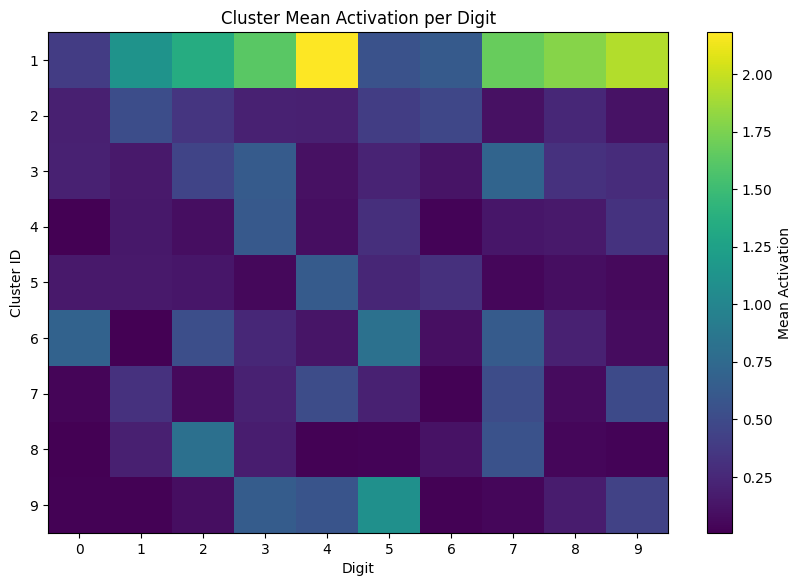


=== layer_1 ===


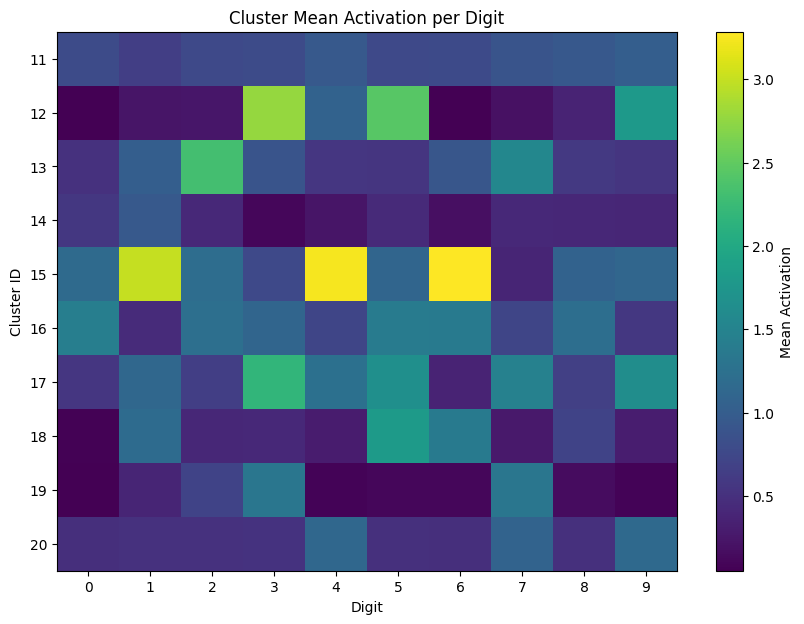


=== layer_2 ===


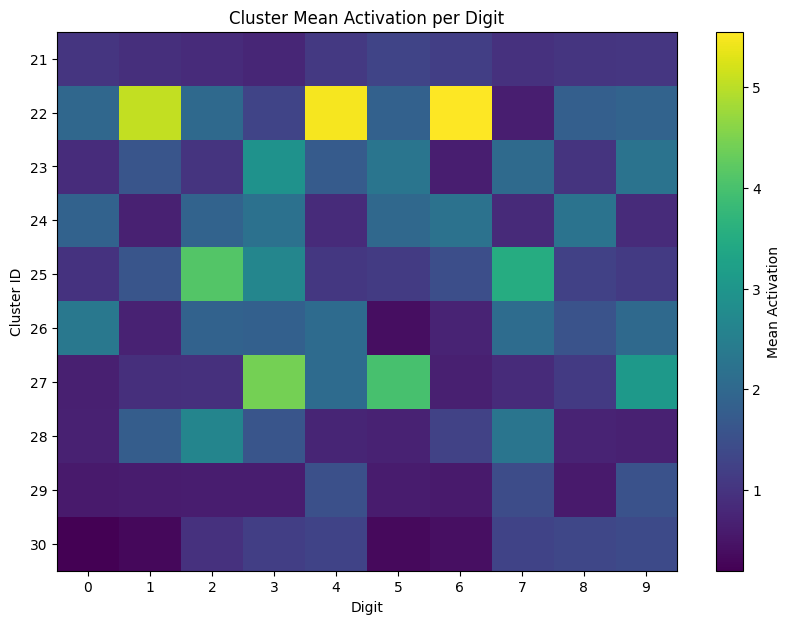


=== layer_3 ===


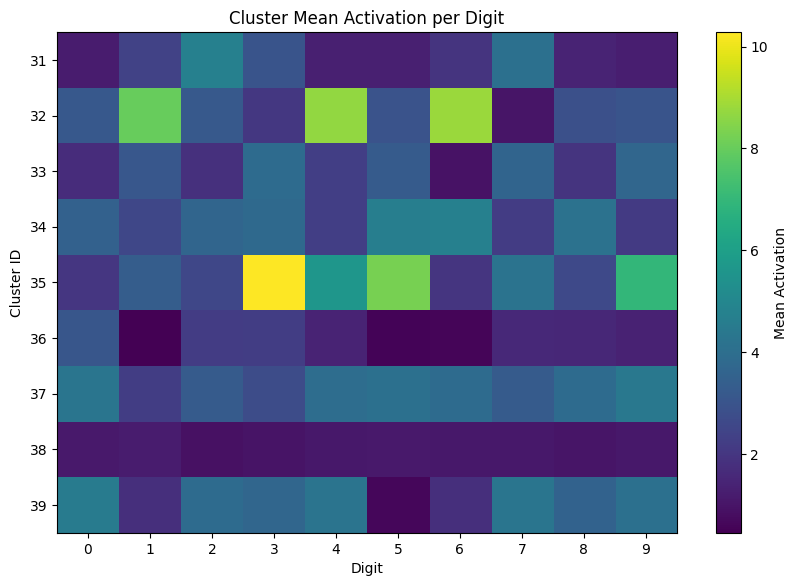

In [66]:
for layer_name, selectivity_results in selectivity_by_layer.items():
    print(f"\n=== {layer_name} ===")
    plots.plot_cluster_activation_heatmap(selectivity_results)

## Cluster ablation

In [67]:
cluster_results_by_layer = {}
for layer_name, layer_clusters in layer_cluster_map.items():
    layer_results = {}
    for cluster_id, neuron_indices in layer_clusters.items():
        per_class_acc = funcs.cluster_criticality_per_class(
            analysis_model,
            neuron_indices,
            layer_mapping,
            val_loader,
            cluster_id,
            device=device
        )
        layer_results[cluster_id] = per_class_acc
    cluster_results_by_layer[layer_name] = layer_results


--- Calculating pre and post-ablation accuracy for cluster 32 ---


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

In [68]:
print(f"Accuracy: {analysis_model.accuracy(val_loader):.2f}")

  0%|          | 0/12 [00:00<?, ?it/s]

Accuracy: 0.96



=== layer_0 ===


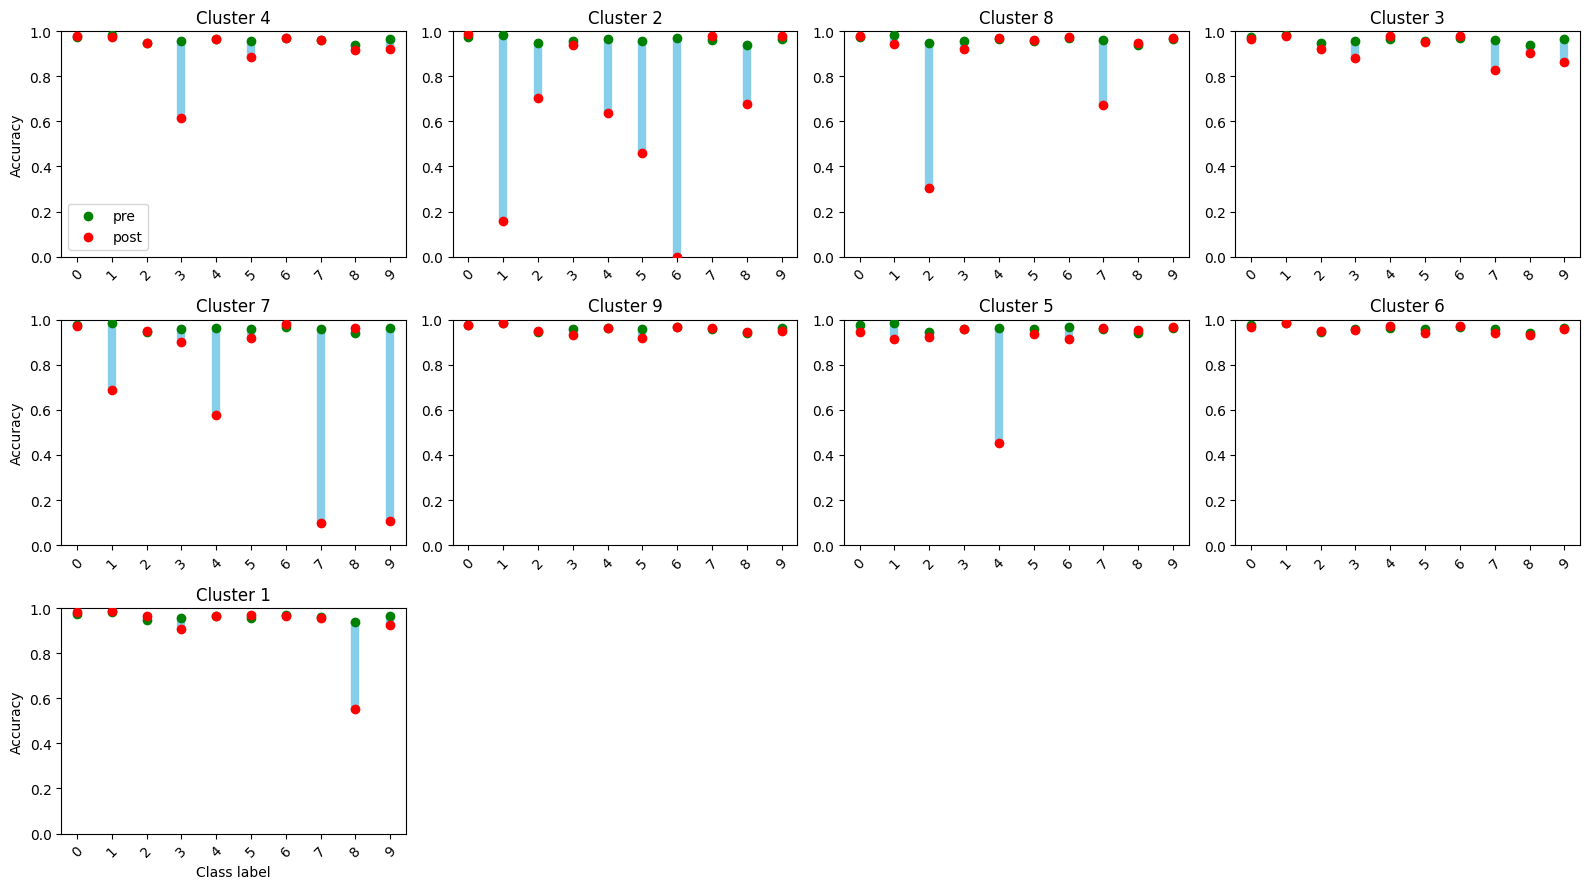


=== layer_1 ===


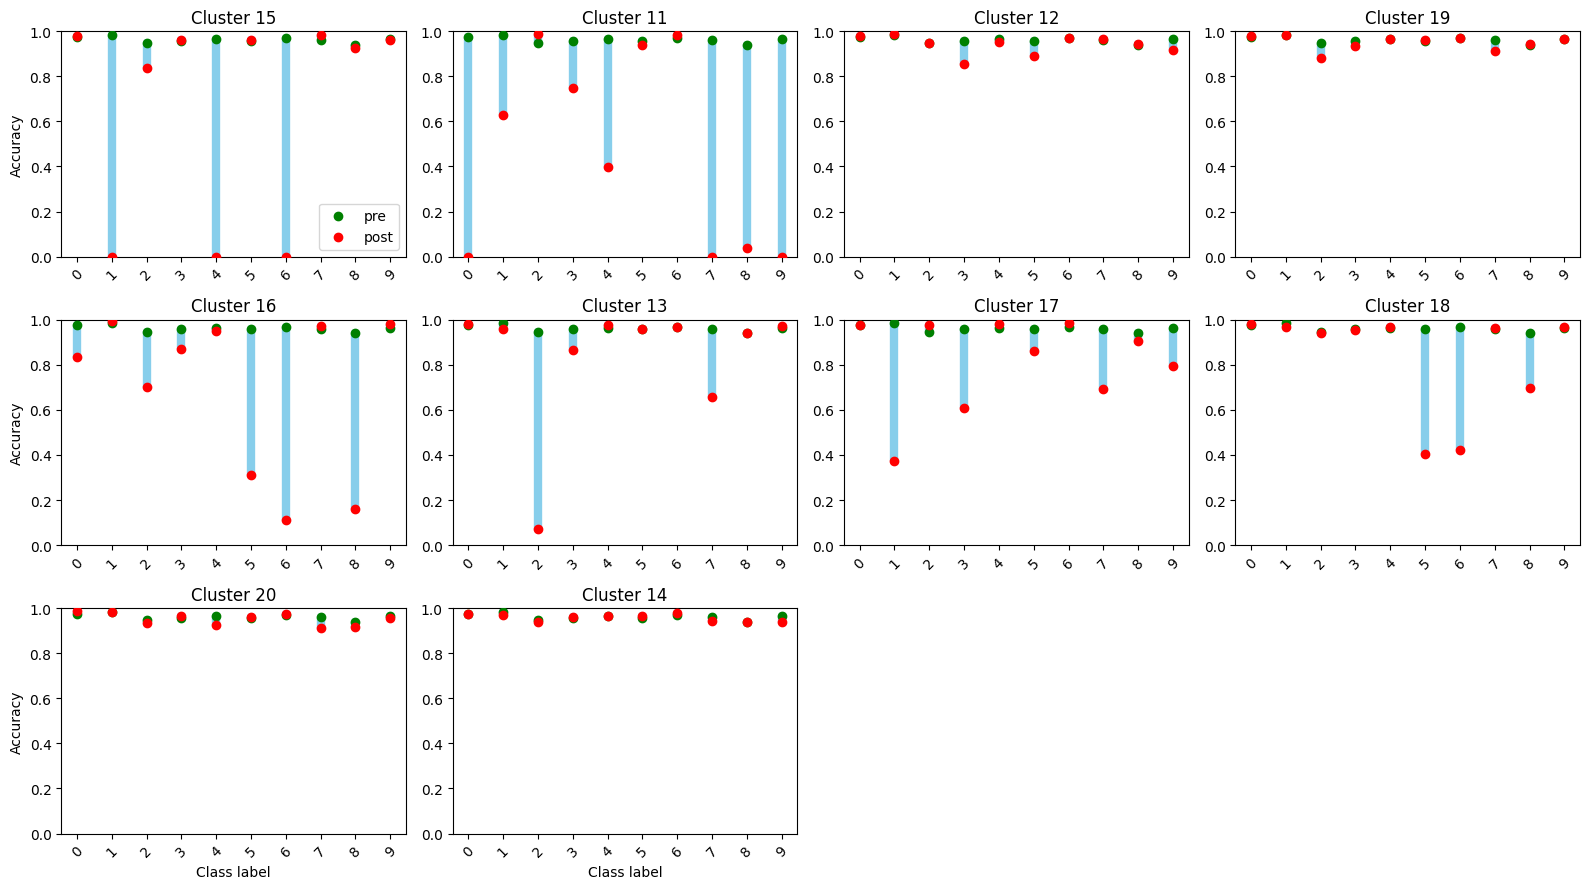


=== layer_2 ===


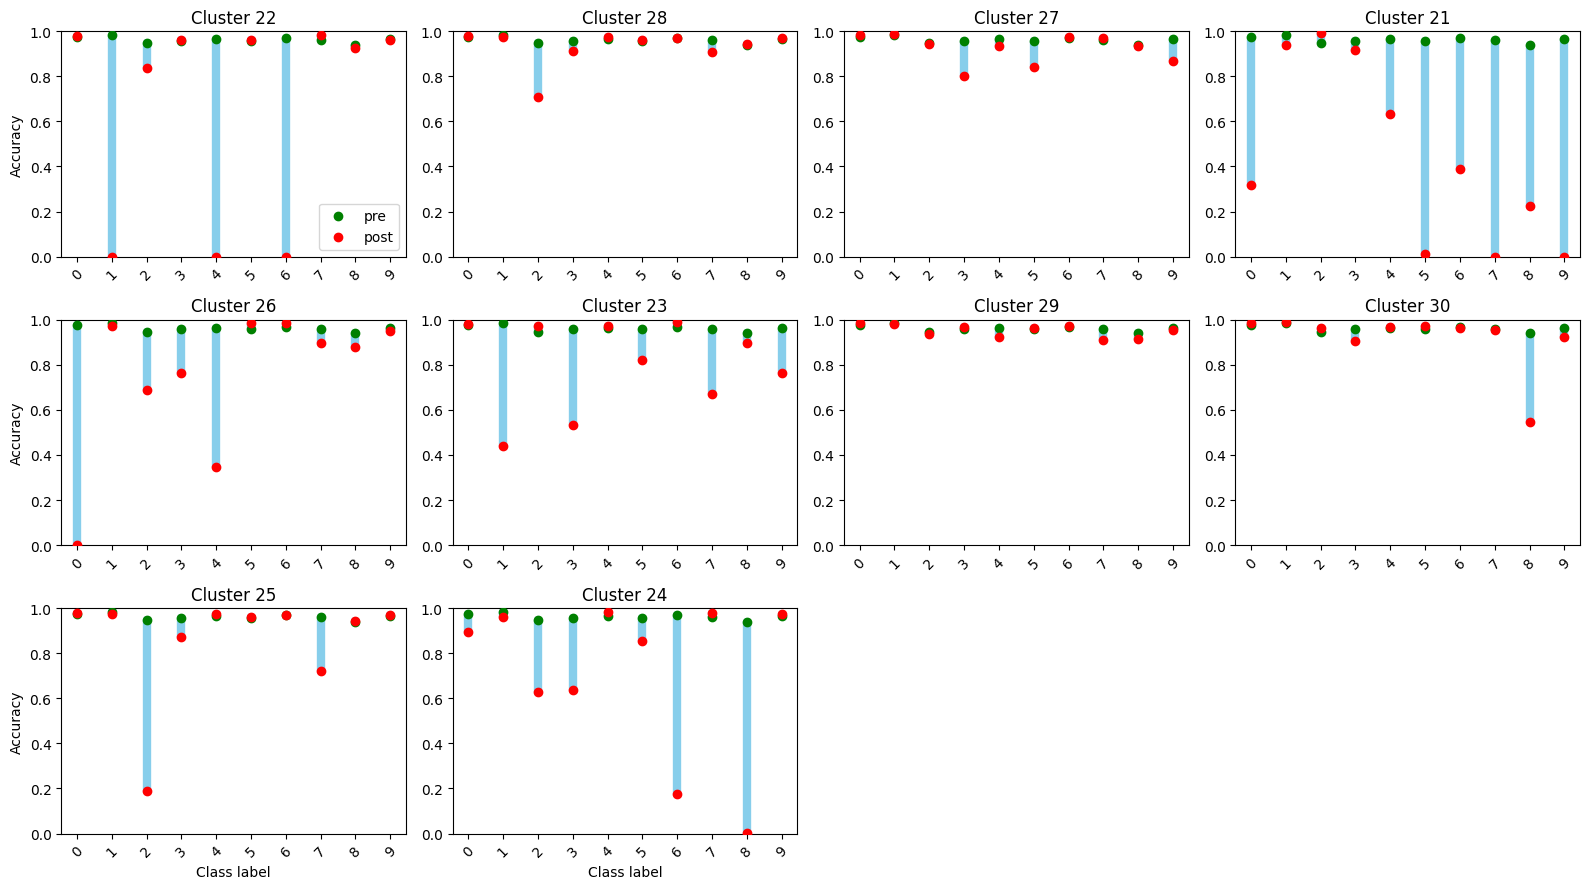


=== layer_3 ===


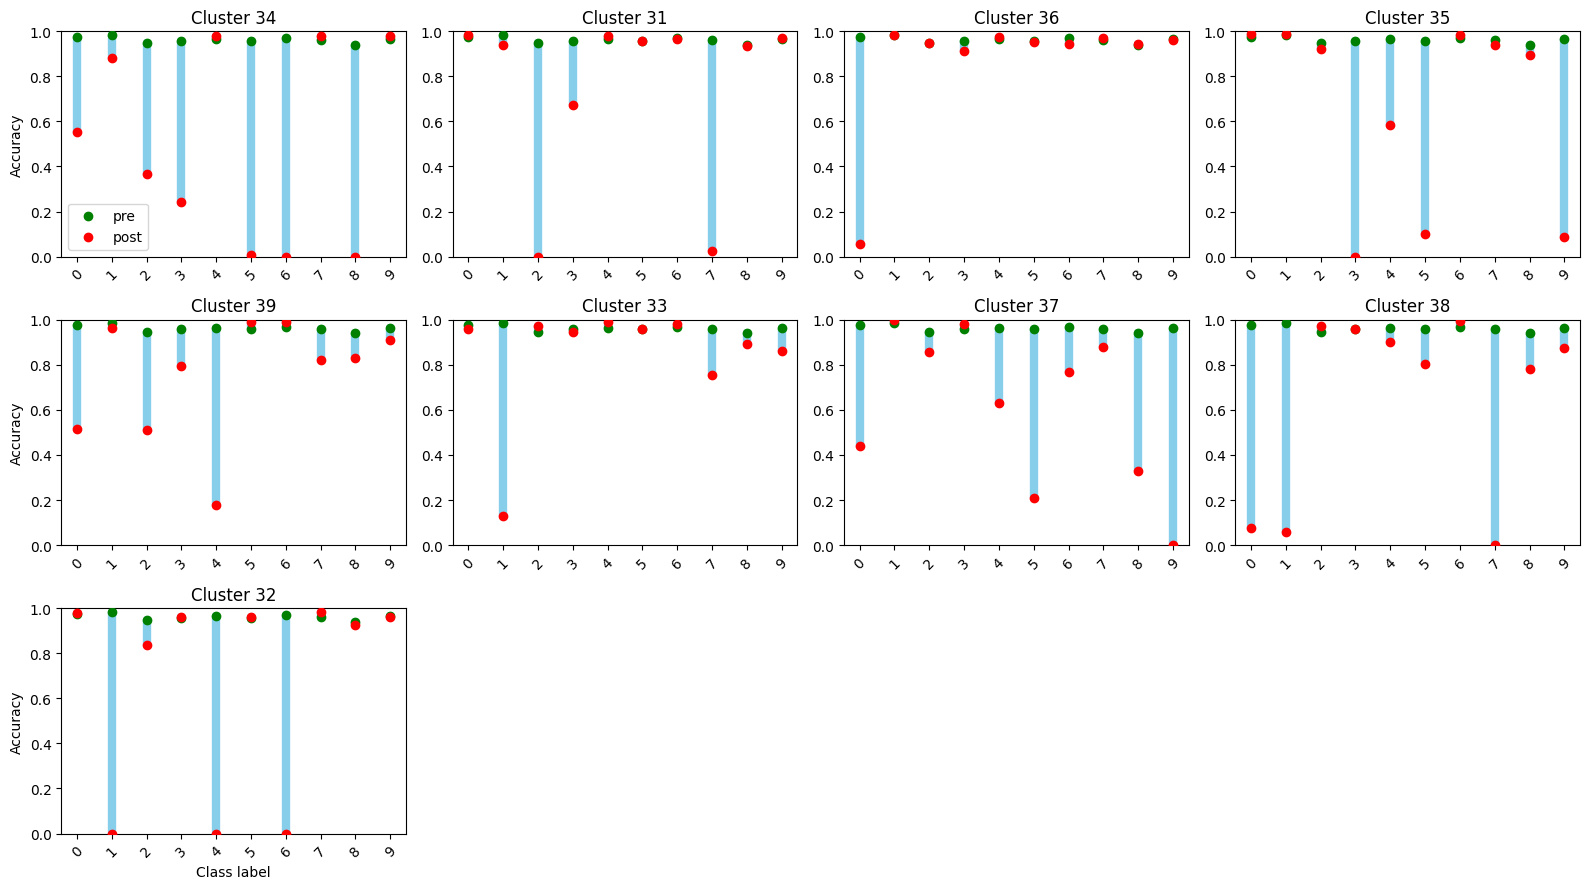

In [69]:
for layer_name, cluster_results in cluster_results_by_layer.items():
    print(f"\n=== {layer_name} ===")
    plots.plot_cluster_accuracy_bars(cluster_results, target_labels=list(range(10)))

## Prototype and difference map plots

In [70]:
all_prototypes_by_layer = {}
for layer_name, layer_clusters in layer_cluster_map.items():
    all_prototypes_by_layer[layer_name] = funcs.compute_prototypes_all_clusters(
        cluster_map=layer_clusters,
        all_activations=all_neuron_activations,
        images=images,
        top_frac=0.1,
        use_global_mean=True
    )


=== layer_0 ===


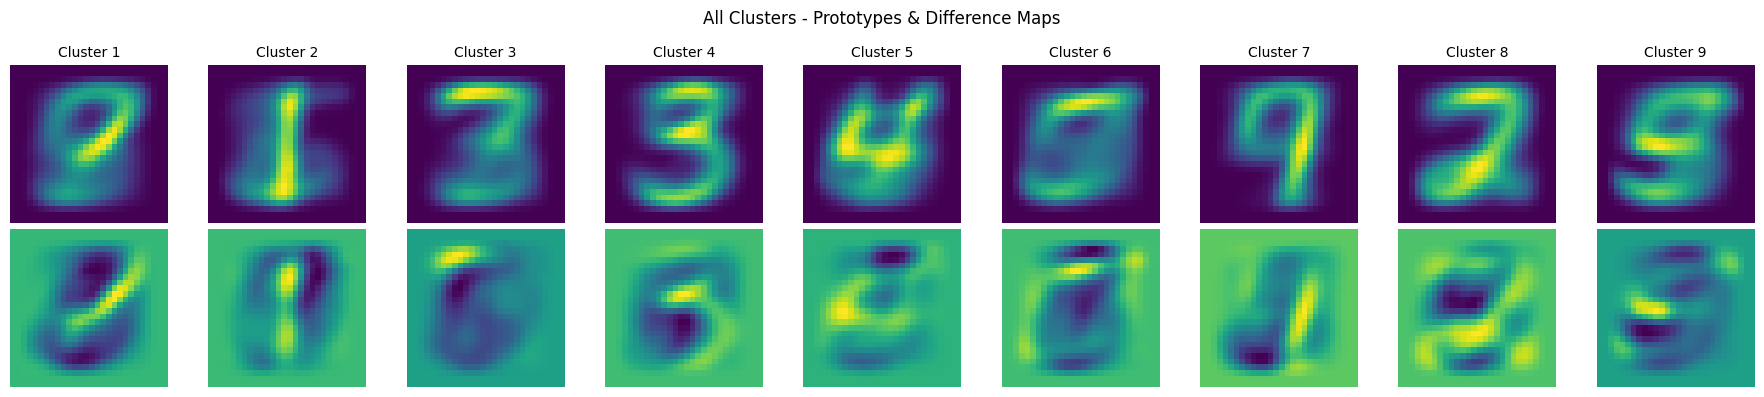


=== layer_1 ===


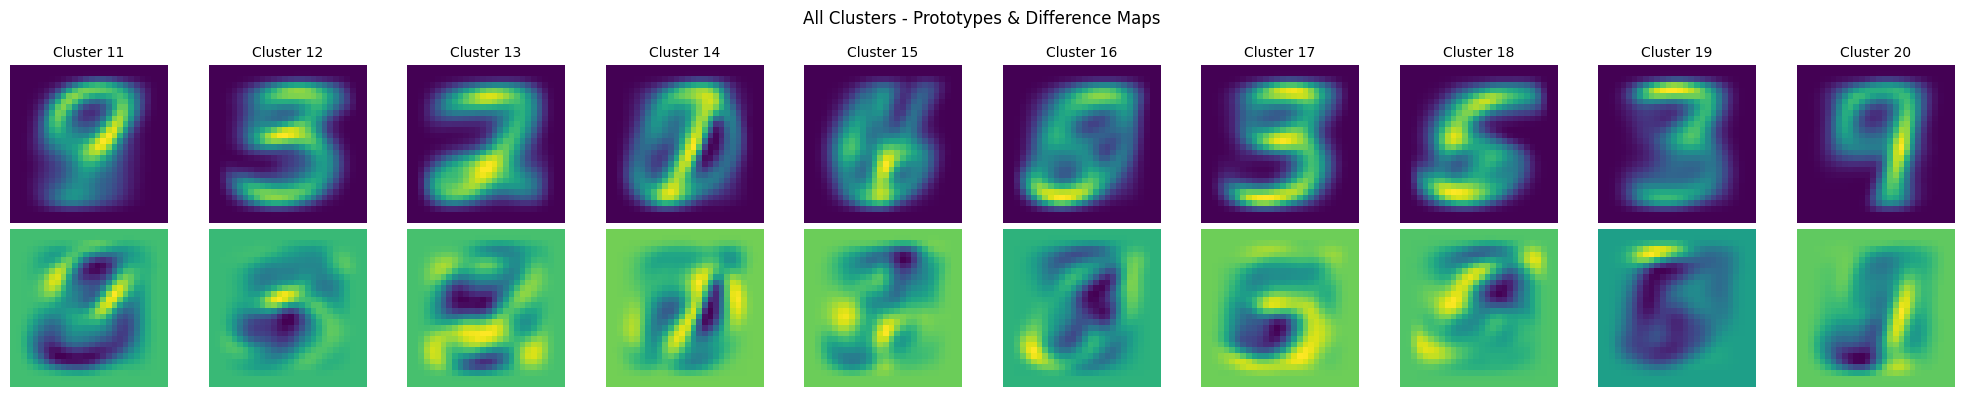


=== layer_2 ===


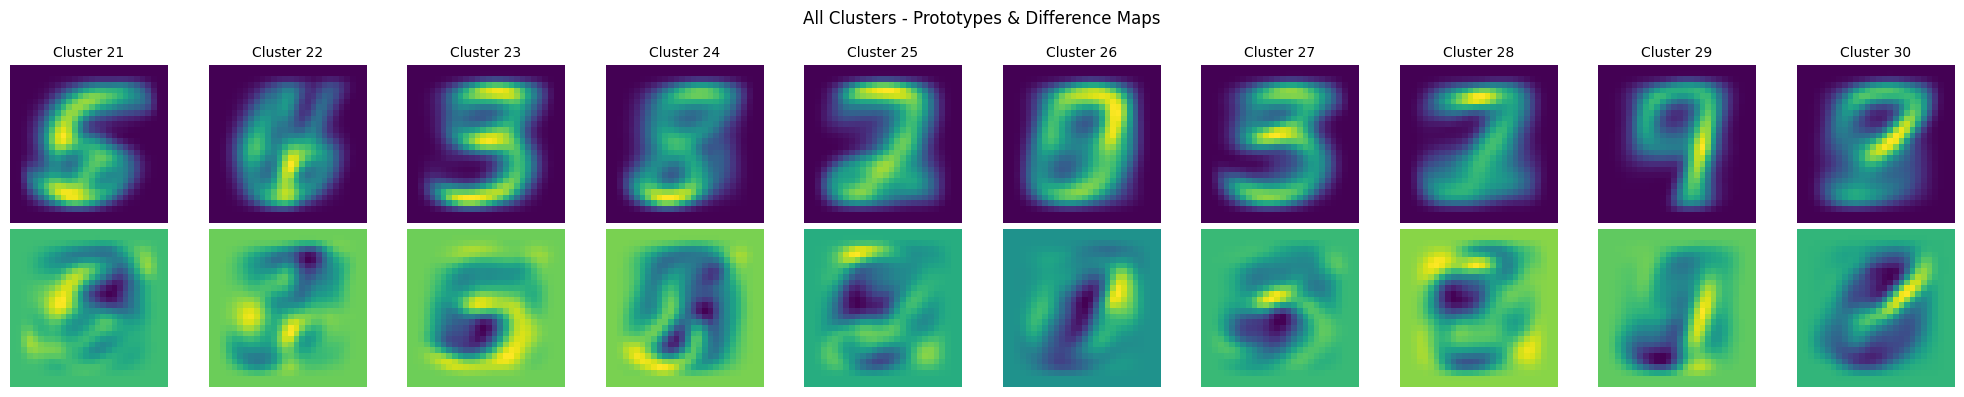


=== layer_3 ===


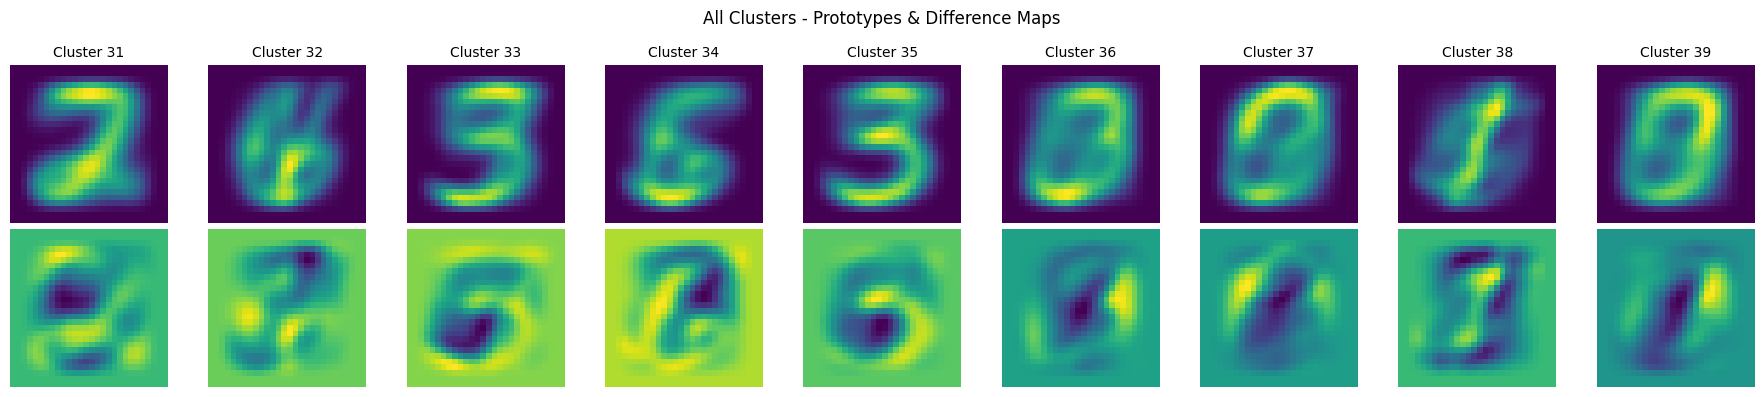

In [71]:
for layer_name, all_prototypes in all_prototypes_by_layer.items():
    print(f"\n=== {layer_name} ===")
    plots.plot_cluster_prototypes_and_diff_all(all_prototypes)

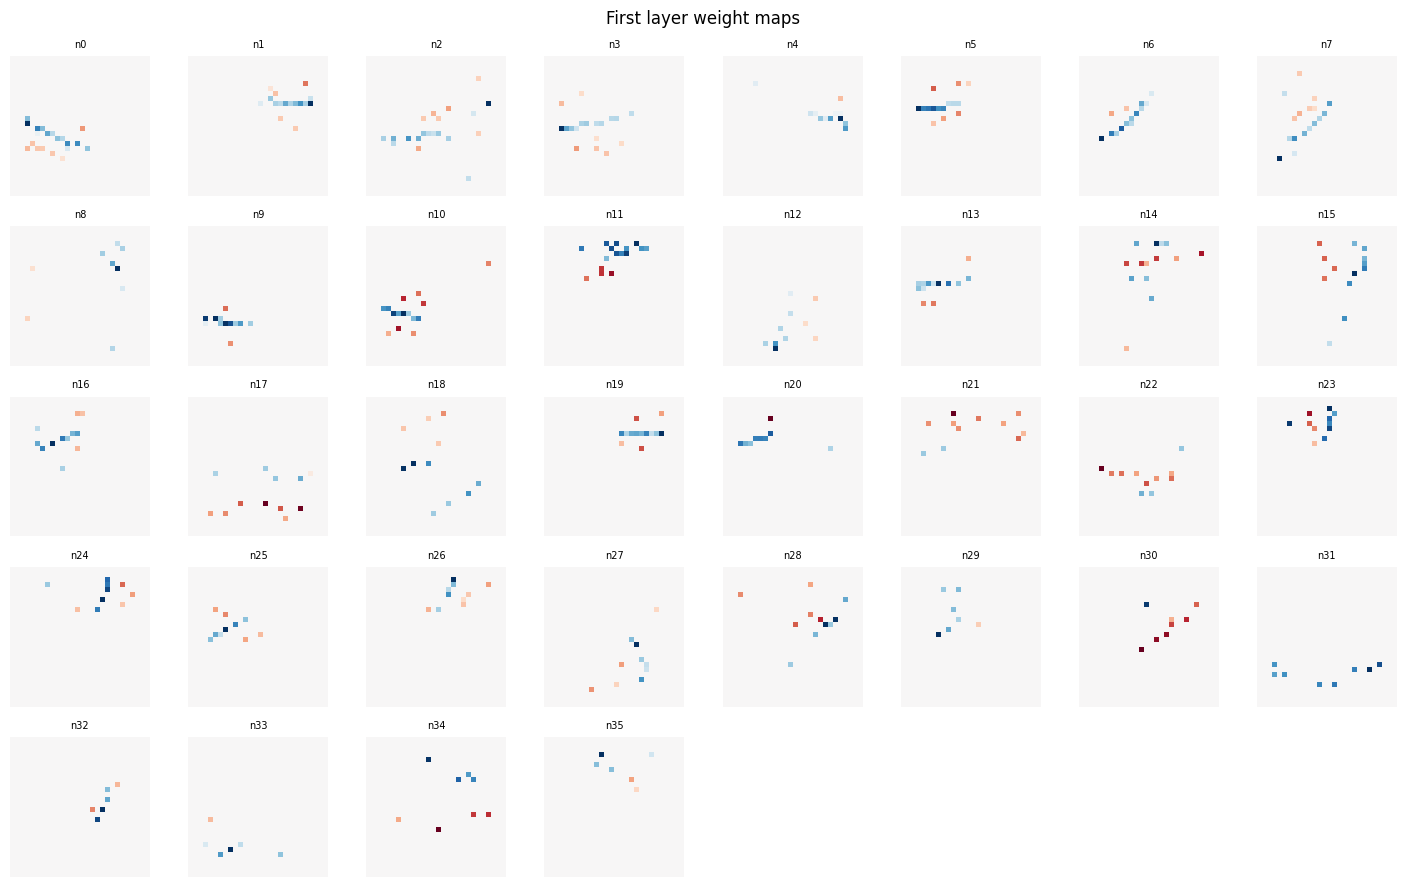

In [8]:
plots.plot_first_layer_weights(analysis_model)

In [ ]:
model = NeuralNetwork(hidden_sizes=[512, 256, 128, 64])
model.train_model(train_loader, epochs=15)

In [12]:
layer_data = model.get_layer_data(train_loader, include_output_layer=True)

  0%|          | 0/48 [00:00<?, ?it/s]

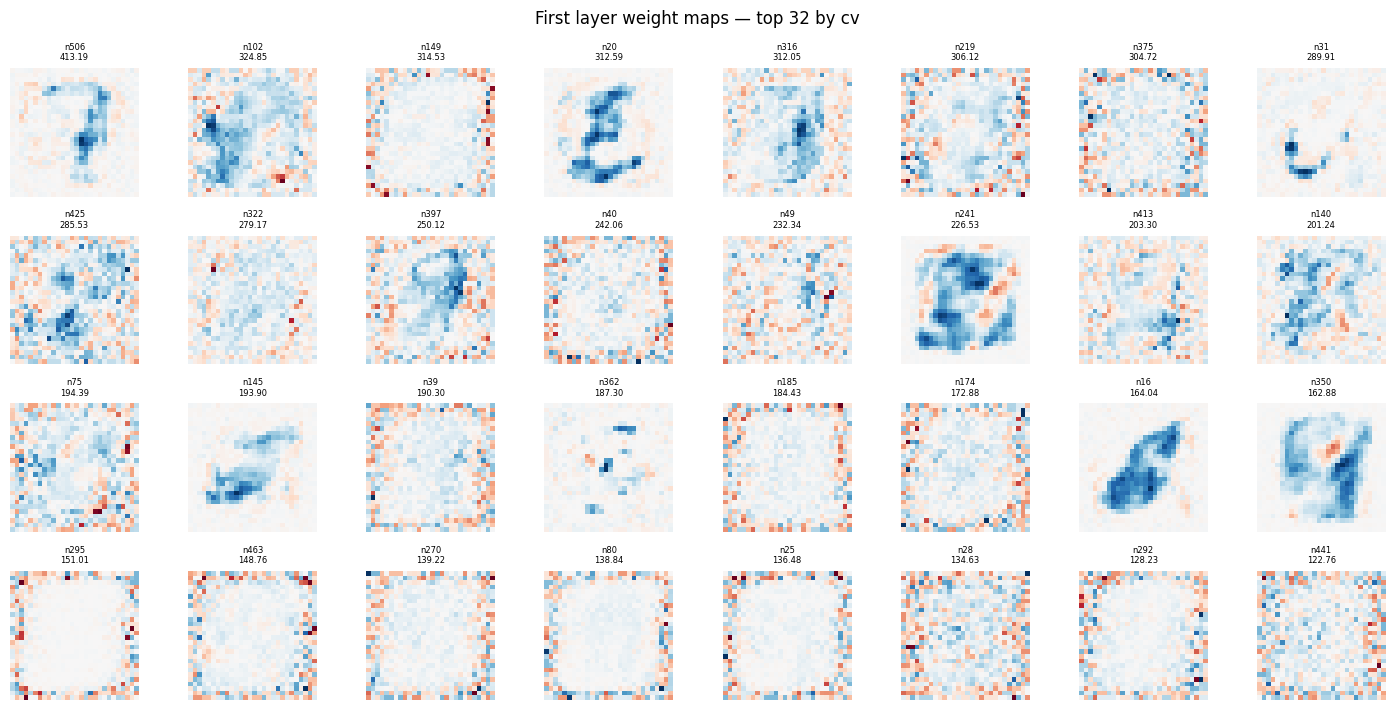

In [16]:
plots.plot_first_layer_weights(model, layer_data=layer_data, sort_by="cv", top_n=32)